# Homework 3: Monte Carlo Radiative Transfer with Scattering and Clouds
## Part III: Cloud Radiative Effects
### 3.1 Model Construction
Updated model from scattering_model.ipynb to take atmospheric parameters as inputs.

In [182]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)

In [183]:
# CONSTANTS
GRAV = 9.8  # m/s2
R = 287  # J/kg/K
SCALE_HEIGHT = 8000  # scale height 8km


def calc_tau(zeta):
    return -1 * np.log(1 - zeta)


def scale_height(t_avg):
    return t_avg * R / GRAV

In [184]:
def coord_rotation_vec(theta0, phi0, theta_sca, phi_sca):
    """Vectorized coordinate rotation for N photons simultaneously.
    All inputs are 1-D arrays of length N; returns (theta_new, phi_new)."""
    k0 = np.column_stack(
        [
            np.cos(phi0) * np.sin(theta0),
            np.sin(phi0) * np.sin(theta0),
            -np.cos(theta0),
        ]
    )  # (N, 3) current direction

    zp = k0
    norm_xy = np.hypot(k0[:, 0], k0[:, 1])
    vert = norm_xy < 1e-10  # photons traveling straight up/down
    safe = np.where(vert, 1.0, norm_xy)

    xp = np.column_stack(
        [
            np.where(vert, 1.0, -k0[:, 1] / safe),
            np.where(vert, 0.0, k0[:, 0] / safe),
            np.zeros(len(theta0)),
        ]
    )  # (N, 3)
    yp = np.cross(zp, xp)  # (N, 3)

    kp = np.column_stack(
        [
            np.sin(theta_sca) * np.cos(phi_sca),
            np.sin(theta_sca) * np.sin(phi_sca),
            np.cos(theta_sca),
        ]
    )  # (N, 3) scattered direction in local frame

    A = np.stack([xp, yp, zp], axis=2)  # (N, 3, 3) rotation matrix
    knew = np.einsum("nij,nj->ni", A, kp)  # (N, 3)
    knew /= np.linalg.norm(knew, axis=1, keepdims=True)

    return (
        np.arccos(np.clip(-knew[:, 2], -1.0, 1.0)),
        np.arctan2(knew[:, 1], knew[:, 0]),
    )


def probability_phase_fnc_hg(cos_theta, g):
    return (1 - g**2) / (1 + g**2 - 2 * g * cos_theta) ** (3 / 2)


def photon_scattering_noniso_vec(theta0, phi0, g, n_grid=2000):
    """
    Vectorized non-isotropic scattering using the Henyey-Greenstein phase function.

    Steps:
      1. Evaluate probability_phase_fnc_hg on a dense grid of cos(theta_scatter)
         to obtain the PDF.
      2. Integrate the PDF numerically (trapezoid rule) to build the CDF.
      3. Draw zeta ~ U[0,1] for each photon and invert the CDF via linear
         interpolation to obtain cos(theta_scatter) — inverse transform sampling.
      4. Draw phi_scatter ~ U[0, 2pi] and rotate the photon direction with
         coord_rotation_vec.

    Parameters
    ----------
    theta0, phi0 : (N,) arrays  current photon directions in radians
    g            : float        HG asymmetry parameter  (-1 <= g <= 1)
                                g = 0  -> isotropic (recovers photon_scattering_iso_vec)
                                g > 0  -> forward-scattering
                                g < 0  -> back-scattering
    n_grid       : int          resolution of the CDF grid (default 2000)
    """
    N = len(theta0)

    # ---- 1. PDF on a dense grid of cos(theta_scatter) -------------------------
    mu_grid = np.linspace(-1.0, 1.0, n_grid)
    pdf = probability_phase_fnc_hg(mu_grid, g)  # shape (n_grid,)

    # ---- 2. CDF via trapezoidal integration, normalized to [0, 1] -------------
    #  cdf[i] = integral of pdf from mu_grid[0] to mu_grid[i]
    cdf = np.zeros(n_grid)
    cdf[1:] = np.cumsum((pdf[:-1] + pdf[1:]) * 0.5 * np.diff(mu_grid))
    cdf /= cdf[-1]  # normalize

    # ---- 3. Inverse transform sampling ----------------------------------------
    #  For each photon draw zeta ~ U[0,1], look up the corresponding cos(theta_scatter)
    #  by interpolating on the (cdf, mu_grid) mapping.
    zeta = np.random.uniform(size=N)
    cos_theta = np.interp(zeta, cdf, mu_grid)  # inverse CDF lookup
    theta_sca = np.arccos(np.clip(cos_theta, -1.0, 1.0))

    # ---- 4. Azimuthal angle is still uniform ----------------------------------
    phi_sca = np.random.uniform(0.0, 2.0 * np.pi, size=N)

    return coord_rotation_vec(theta0, phi0, theta_sca, phi_sca)

In [185]:
# direct    == first hop hits surface  (n_scatter == 0, z < 0)
# diffuse   == scattered at least once, then exits at surface (n_scatter > 0, z < 0)
# albedo    == exits at TOA           (z > H)
# absorbed  == none of the above


def monte_carlo_model(theta, regimes={'clear_sky':{'g':0,'w':0.5,'min':0,'max':SCALE_HEIGHT,'tau_star':1}}, num_photons=10e4, ext_event_count=False):
    N = int(num_photons)
    theta_rad = np.deg2rad(theta)

    # Per-photon state
    z = np.full(N, float(SCALE_HEIGHT))
    theta_arr = np.full(N, theta_rad)
    phi_arr   = np.zeros(N)
    active    = np.ones(N, dtype=bool)
    n_scatter = np.zeros(N, dtype=int)

    # Outcome masks
    direct_mask = np.zeros(N, dtype=bool)
    diffuse_mask = np.zeros(N, dtype=bool)
    albedo_mask  = np.zeros(N, dtype=bool)

    # Sort regimes by altitude once (bottom → top)
    regime_list = sorted(regimes.values(), key=lambda r: r['min'])
    n_regimes   = len(regime_list)

    while active.any():
        idx       = np.where(active)[0]
        n_active  = len(idx)
        cos_theta = np.cos(theta_arr[idx])

        # ── Assign initial regime index by z position ──────────────────────────
        # Processing bottom→top means higher regimes overwrite lower ones at shared
        # boundaries, so a photon at an exact boundary is placed in the upper regime.
        regime_idx = np.zeros(n_active, dtype=int)
        for ri, rp in enumerate(regime_list):
            in_r = (z[idx] >= rp['min']) & (z[idx] <= rp['max'])
            regime_idx[in_r] = ri

        # Per-photon regime parameters (updated as photons cross boundaries)
        g_arr     = np.zeros(n_active)
        w_arr     = np.zeros(n_active)
        depth_arr = np.zeros(n_active)
        tau_arr   = np.zeros(n_active)
        for ri, rp in enumerate(regime_list):
            in_r = (regime_idx == ri)
            g_arr[in_r]     = rp['g']
            w_arr[in_r]     = rp['w']
            depth_arr[in_r] = rp['max'] - rp['min']
            tau_arr[in_r]   = rp['tau_star']

        # ── Sample optical depth; track the remaining budget across layers ──────
        # tau_total = -log(1-zeta) is the full optical depth to the next event.
        # As the photon passes through each layer it consumes part of that budget:
        #   tau_consumed = path_length_to_boundary * (tau_star / depth)
        # Only tau_remaining drives the path in the next layer.
        zeta        = np.random.uniform(size=n_active)
        tau_remain  = -np.log(1.0 - zeta)   # remaining optical depth budget
        z_curr      = z[idx].copy()

        # ── Propagate, resolving regime boundary crossings ─────────────────────
        for _ in range(n_regimes):
            L      = depth_arr * tau_remain / tau_arr
            z_next = z_curr - L * cos_theta

            # Detect which photons crossed an internal boundary this sub-step
            new_ri  = np.full(n_active, -1, dtype=int)   # -1 → no crossing
            z_bound = np.zeros(n_active)

            for ri, rp in enumerate(regime_list):
                in_r = (regime_idx == ri)
                # Downward: exits through bottom of current regime (not the surface)
                c_down = in_r & (cos_theta > 0) & (z_next < rp['min']) & (rp['min'] > 0)
                # Upward: exits through top of current regime (not the TOA)
                c_up   = in_r & (cos_theta < 0) & (z_next > rp['max']) & (rp['max'] < SCALE_HEIGHT)

                new_ri[c_down]  = ri - 1
                z_bound[c_down] = rp['min']
                new_ri[c_up]    = ri + 1
                z_bound[c_up]   = rp['max']

            crossed = new_ri >= 0
            if not crossed.any():
                break

            # Deduct the optical depth consumed travelling to the boundary.
            # path_length_to_boundary = |dz| / |cos_theta|; tau_consumed = that * tau_star/depth
            dz_to_bound           = np.abs(z_curr[crossed] - z_bound[crossed])
            tau_consumed          = dz_to_bound * tau_arr[crossed] / (depth_arr[crossed] * np.abs(cos_theta[crossed]))
            tau_remain[crossed]  -= tau_consumed

            # Place photon at the boundary; assign new regime params
            z_curr[crossed]     = z_bound[crossed]
            regime_idx[crossed] = new_ri[crossed]
            for ri, rp in enumerate(regime_list):
                entering = crossed & (new_ri == ri)
                if entering.any():
                    g_arr[entering]     = rp['g']
                    w_arr[entering]     = rp['w']
                    depth_arr[entering] = rp['max'] - rp['min']
                    tau_arr[entering]   = rp['tau_star']

        z_new = z_next

        hit_sfc  = z_new < 0
        hit_toa  = z_new > SCALE_HEIGHT
        # Scatter/absorb: independent draw; compare against per-photon w
        zeta_sca = np.random.uniform(size=n_active)
        scatter  = ~hit_sfc & ~hit_toa & (zeta_sca < w_arr)

        z[idx] = z_new

        # Classify exits
        first_hop = n_scatter[idx] == 0
        direct_mask[idx[hit_sfc & first_hop]]  = True
        diffuse_mask[idx[hit_sfc & ~first_hop]] = True
        albedo_mask[idx[hit_toa]]               = True

        # Deactivate photons that exited or were absorbed
        active[idx[~scatter]] = False

        # Update direction for scattering photons, grouped by regime g value
        scat_idx = idx[scatter]
        if len(scat_idx):
            scat_g = g_arr[scatter]
            for g_val in np.unique(scat_g):
                grp = scat_idx[scat_g == g_val]
                theta_arr[grp], phi_arr[grp] = photon_scattering_noniso_vec(
                    theta_arr[grp], phi_arr[grp], g=g_val
                )
            n_scatter[scat_idx] += 1

    results = [int(direct_mask.sum()), int(diffuse_mask.sum()), int(albedo_mask.sum())]

    if ext_event_count:
        ext = n_scatter + 1  # total extinction events = scatter hops + initial hop
        results += [
            float(ext[direct_mask].mean()) if direct_mask.any() else np.nan,
            float(ext[diffuse_mask].mean()) if diffuse_mask.any() else np.nan,
            float(ext[albedo_mask].mean()) if albedo_mask.any() else np.nan,
        ]

    return results

In [186]:
cloudy_atm = {
    'top_sky':{
        'w':1,
        'g':0,
        'min':1000,
        'max':SCALE_HEIGHT,
        # 'tau_star': 0.5
    },
    'cloud':{
        'w':1,
        'g':0.8,
        'min':750,
        'max':1000,
        # 'tau_star':0,
    },
    'bottom_sky':{
        'w':1,
        'g':0,
        'min':0,
        'max':750,
        'tau_star': 0.5
    }
}

cloudy_atm['top_sky']['tau_star'] = cloudy_atm['bottom_sky']['tau_star']*np.exp(-cloudy_atm['top_sky']['min']/SCALE_HEIGHT)

lwc = 0.32 * 1 / 1000 # kg/m**3
dz = 250 # m
rho_l = 1000 # kg/m**3
r_eff = 11 * 10**-6 # m
cloudy_atm['cloud']['tau_star'] = 3 * lwc * dz / (2 * rho_l * r_eff)

### 3.2 Model Verification
<!-- - Verification of solar zenith angle
    - for low SZA, albedo should be 100 -->
- Verification of cloud properties (tau ~ 10)
    - when omega = 0, direct and diffuse transmittance should be zero.
    - when g = -0.99, direct should be zero and diffuse transmittance should be very low.
- When atmosphere is transparent (tau=0) except for a thin cloud layer (tau = 1), the direct, diffuse, and albedo should not be a function of the height of the cloud layer.

In [187]:
verif_1_atm = cloudy_atm
verif_1_atm['cloud']['w'] = 0
print(np.array(monte_carlo_model(theta = 89, regimes = verif_1_atm))*100 / 10e4)
verif_1_atm['cloud']['w'] = 1
verif_1_atm['cloud']['g'] = -0.99
print(np.array(monte_carlo_model(theta = 89, regimes = verif_1_atm))*100 / 10e4)

[ 0.     0.    65.542]
[ 0.     2.554 97.446]


In [188]:
dz = 500
df = pd.DataFrame({
    'cloud_top':np.linspace(dz + 1,SCALE_HEIGHT - 1,50)
})

def calc_atm(cld_top):
    verif_2_atm = {
        'top_sky':{
            'w':1,
            'g':0,
            # 'min':1000,
            'max':SCALE_HEIGHT,
            'tau_star': 0
        },
        'cloud':{
            'w':1,
            'g':0,
            # 'min':750,
            # 'max':1000,
            'tau_star':1,
        },
        'bottom_sky':{
            'w':1,
            'g':0,
            'min':0,
            # 'max':750,
            'tau_star': 0
        }
    }
    verif_2_atm['top_sky']['min'] = cld_top

    verif_2_atm['cloud']['max'] = cld_top
    verif_2_atm['cloud']['min'] = cld_top - dz

    verif_2_atm['bottom_sky']['max'] = cld_top - dz

    return verif_2_atm



df['atm'] = df.apply(lambda x: calc_atm(x['cloud_top']),axis=1)

df_results = df.apply(lambda x: monte_carlo_model(theta = 0, regimes = x['atm']), axis=1,result_type = 'expand')
df_results = (df_results * 100 / 10e4).rename(columns={0:'direct',1:'diffuse',2:'albedo'})
df = pd.concat([df,df_results],axis=1)

/var/folders/ys/qmftlyyx3dj63021dv4205g80000gn/T/ipykernel_94469/2195131291.py:63: RuntimeWarning: divide by zero encountered in divide
  L      = depth_arr * tau_remain / tau_arr


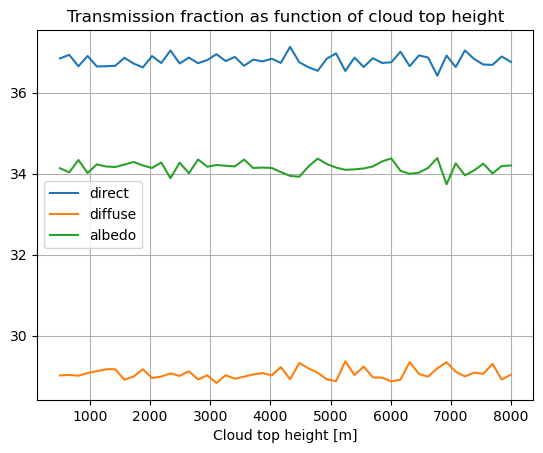

In [189]:
df.drop(columns=['atm']).set_index('cloud_top').plot()
plt.xlabel('Cloud top height [m]')
plt.title("Transmission fraction as function of cloud top height")
plt.grid()
plt.savefig('figures/verification_cloud_top_height.png', dpi=150, bbox_inches='tight')

### 3.3 Questions
What is the SW cloud radiative effect (CRE) at the top of the atmosphere (W m−2)?

In [190]:
clear_sky = {
    'all_sky':{
        'w':1,
        'g':0,
        'min':0,
        'max':SCALE_HEIGHT,
        'tau_star': 0.5
    },
}

num_photons = 10e4

toa_sw_clr_pct = np.array(monte_carlo_model(theta = 0, regimes = clear_sky))[2] / num_photons
toa_sw_cld_pct = np.array(monte_carlo_model(theta = 0, regimes = cloudy_atm))[2] / num_photons

In [200]:
# SWCRE = S0/4 * (TOA,SW_CLD - TOA,SW_CLR)

s0 = -1361 # W/m2
swcre = s0 / 4 * (toa_sw_cld_pct - toa_sw_clr_pct)
print(f"Short wave cloud radiative effect: {swcre.round(3)} W/m**2")

Short wave cloud radiative effect: -246.807 W/m**2


Vary Reff from half to double the initial value while holding LWC and the cloud geometric dimensions constant. Plot the CRE as a function of Reff and calculate the slope of this line (units of W m−2 µm−1). This is the first aerosol indirect effect.

In [192]:
r_eff_arr = np.linspace(r_eff/2,r_eff*2,100)
df = pd.DataFrame({'r_eff':r_eff_arr})
df['cloud_tau_star'] = 3 * lwc * dz / (2 * rho_l * df['r_eff'])

df['cloud_atm'] = df.apply(lambda x: {
    'top_sky':{
        'w':1,
        'g':0,
        'min':1000,
        'max':SCALE_HEIGHT,
        'tau_star': 0.5*np.exp(-1000/SCALE_HEIGHT),
    },
    'cloud':{
        'w':1,
        'g':0.8,
        'min':750,
        'max':1000,
        'tau_star':x['cloud_tau_star'],
    },
    'bottom_sky':{
        'w':1,
        'g':0,
        'min':0,
        'max':750,
        'tau_star': 0.5
    }
},axis=1)

In [193]:
df['cre_sw_cld'] = df.apply(lambda x: np.array(monte_carlo_model(theta = 0, regimes = x['cloud_atm']))[2] / num_photons,axis=1)
df['sw_cre'] = s0 / 4 * (toa_sw_clr_pct - df['cre_sw_cld'])

In [194]:
reg = LinearRegression().fit(df[['r_eff']], df[['sw_cre']])
slope = reg.coef_[0] / 10**6 # convert to w/m**2 / um

df['linear_fit'] = reg.predict(df[['r_eff']])
print(f'First aerosol indirect effect: {slope[0].round(3)} W/m**2/um')

First aerosol indirect effect: 4.397 W/m**2/um


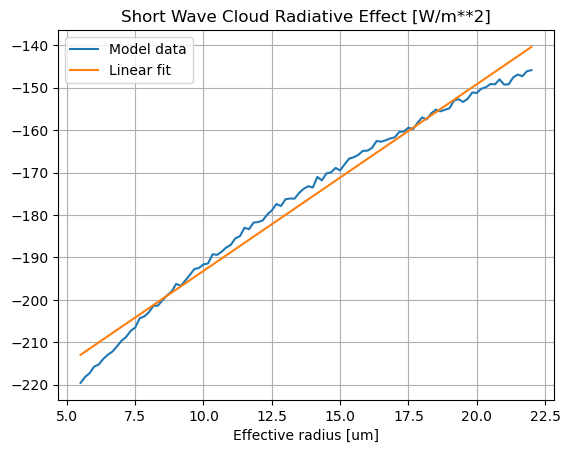

In [195]:
plt.plot(df['r_eff'] * 10**6, df['sw_cre'], label='Model data')
plt.plot(df['r_eff'] * 10**6, df['linear_fit'], label='Linear fit')
plt.grid()
plt.xlabel('Effective radius [um]')
plt.title('Short Wave Cloud Radiative Effect [W/m**2]')
plt.legend()
plt.savefig('figures/sw_cre_vs_r_eff.png', dpi=150, bbox_inches='tight')

### 3.4 Question and Hypothesis
- Question:     How does the order of an aerosol and cloud layer impact transmission fractions?
- Hypothesis:   Having a cloud layer above the aerosol layer will increase the albedo, but the surface transmission (direct and diffuse) will not change.

We derived this relationship with the two-stream radiative transfer model, but I want to prove it with the Monte Carlo model. I also want to see how well this relationship holds for different single scatter albedo values. 

- Steps:
    - Define an atmospheric profile that includes:
        - clear sky top of atmosphere
        - aerosol (cloud) layer
        - clear sky middle of atmosphere
        - cloud (aerosol) layer
        - clear sky bottom of atmosphere
    - Clear sky atmosphere has the same properties defined in the prior section
    - Cloud layer with the same omega and g defined in the prior section
        - I don't want total extinction so I will decrease optical depth to 5
    - Aerosol layer has
        - tau star = 2
        - omega = 0.5
        - g = 0.55 [(Andrews et al., 2006)](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2004JD005734)
        - depth = 250 m
        - layer top height = 3,250 m
    - Calculate transmission fractions for all SZA
    - Repeat above steps for omega values ranging from 0 - 1

In [196]:
def atm_layers_experiment(aerosol_omega = 1):
    cloud_top_atm = {
        'top_sky':{
            'w':1,
            'g':0,
            'min':3250,
            'max':SCALE_HEIGHT,
            'tau_star': 0.5*np.exp(-3250/SCALE_HEIGHT)
        },
        'cloud':{
            'w':1,
            'g':0.8,
            'min':3000,
            'max':3250,
            'tau_star':5,
        },
        'middle_sky':{
            'w':1,
            'g':0,
            'min':1000,
            'max':3000,
            'tau_star': 0.5*np.exp(-1000/SCALE_HEIGHT)
        },
        'aerosol':{
            'w':aerosol_omega,
            'g':0.55,
            'min':750,
            'max':1000,
            'tau_star':2,
        },
        'bottom_sky':{
            'w':1,
            'g':0,
            'min':0,
            'max':750,
            'tau_star': 0.5
        }
    }

    df_sza_cloud_top = pd.DataFrame({
        'theta':np.linspace(0,85,20)
    })
    df_sza_cloud_top[['direct','diffuse','albedo']] = df_sza_cloud_top.apply(lambda x: monte_carlo_model(theta = x['theta'], regimes = cloud_top_atm),axis=1,result_type = 'expand')

    df_sza_cloud_top['scene_t'] = (df_sza_cloud_top['direct'] + df_sza_cloud_top['diffuse']) / num_photons
    df_sza_cloud_top['scene_r'] = df_sza_cloud_top['albedo'] / num_photons


    aerosol_top_atm = {
        'top_sky':{
            'w':1,
            'g':0,
            'min':3250,
            'max':SCALE_HEIGHT,
            'tau_star': 0.5*np.exp(-3250/SCALE_HEIGHT)
        },
        'aerosol':{
            'w':aerosol_omega,
            'g':0.55,
            'min':3000,
            'max':3250,
            'tau_star':2,
        },
        'middle_sky':{
            'w':1,
            'g':0,
            'min':1000,
            'max':3000,
            'tau_star': 0.5*np.exp(-1000/SCALE_HEIGHT)
        },
        'cloud':{
            'w':1,
            'g':0.8,
            'min':750,
            'max':1000,
            'tau_star':5,
        },
        'bottom_sky':{
            'w':1,
            'g':0,
            'min':0,
            'max':750,
            'tau_star': 0.5
        }
    }

    df_sza_aerosol_top = pd.DataFrame({
        'theta':np.linspace(0,85,20)
    })
    df_sza_aerosol_top[['direct','diffuse','albedo']] = df_sza_aerosol_top.apply(lambda x: monte_carlo_model(theta = x['theta'], regimes = aerosol_top_atm),axis=1,result_type = 'expand')

    df_sza_aerosol_top['scene_t'] = (df_sza_aerosol_top['direct'] + df_sza_aerosol_top['diffuse']) / num_photons
    df_sza_aerosol_top['scene_r'] = df_sza_aerosol_top['albedo'] / num_photons

    return df_sza_cloud_top, df_sza_aerosol_top

In [197]:
omega_values = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
results = {}
for omega in omega_values:
    df_ct, df_at = atm_layers_experiment(aerosol_omega=omega)
    results[omega] = (df_ct, df_at)

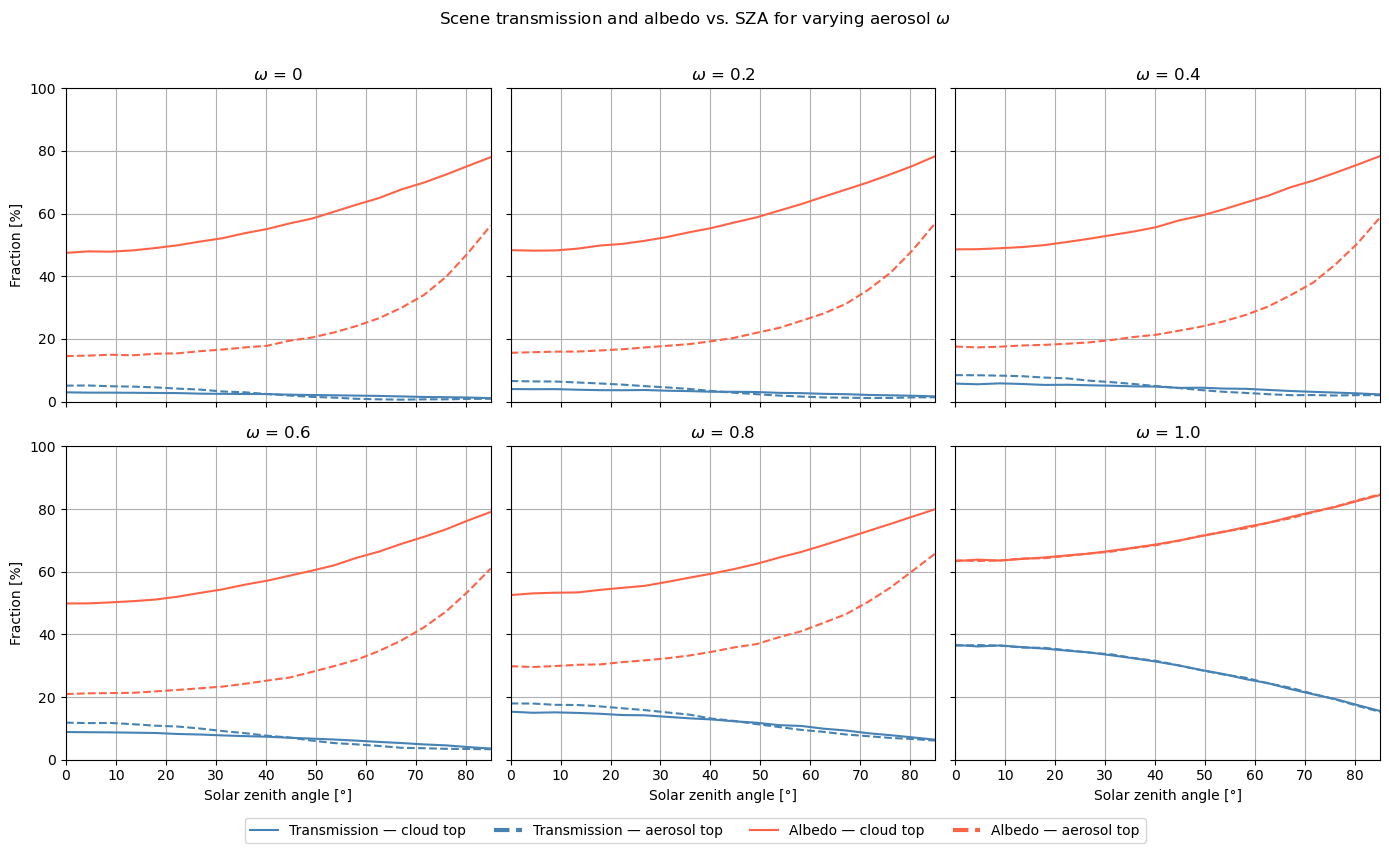

In [198]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True, sharex=True)

T_COLOR = 'steelblue'
R_COLOR = 'tomato'

for ax, omega in zip(axes.flat, omega_values):
    df_ct, df_at = results[omega]
    theta = df_ct['theta']

    ax.plot(theta, df_ct['scene_t'] * 100, color=T_COLOR, linestyle='-')
    ax.plot(df_at['theta'], df_at['scene_t'] * 100, color=T_COLOR, linestyle='--')
    ax.plot(theta, df_ct['scene_r'] * 100, color=R_COLOR, linestyle='-')
    ax.plot(df_at['theta'], df_at['scene_r'] * 100, color=R_COLOR, linestyle='--')

    ax.set_title(f'$\\omega$ = {omega}')
    ax.grid(True)
    ax.set_xlim(0, 85)
    ax.set_ylim(0, 100)

for ax in axes[1]:
    ax.set_xlabel('Solar zenith angle [°]')
for ax in axes[:, 0]:
    ax.set_ylabel('Fraction [%]')

legend_lines = [
    plt.Line2D([0], [0], color=T_COLOR, linestyle='-',  label='Transmission — cloud top'),
    plt.Line2D([0], [0], color=T_COLOR, linestyle='--', linewidth=3, label='Transmission — aerosol top'),
    plt.Line2D([0], [0], color=R_COLOR, linestyle='-',  label='Albedo — cloud top'),
    plt.Line2D([0], [0], color=R_COLOR, linestyle='--', linewidth=3, label='Albedo — aerosol top'),
]
fig.legend(handles=legend_lines, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.04), frameon=True)

fig.suptitle('Scene transmission and albedo vs. SZA for varying aerosol $\\omega$', y=1.01)
plt.tight_layout()
plt.savefig('figures/aerosol_cloud_layer_order.png', dpi=150, bbox_inches='tight')
plt.show()

### Results
My hypothesis was mostly correct. The albedo is significantly larger when the cloud layer is above the aerosol layer. The difference between the two cases decreases with increasing single scatter albedo. Although even with a single scatter albedo of 0.8, the difference is still quite large. At a single scatter albedo of 1, the two scenarios collapse on top of each other. This case could then be modeled instead as a combined cloud/aerosol layer. The surface transmission is close to equal, but not exactly. The aerosol top case consistently has more surface transmission for low SZA, less for high SZA, and equal when SZA >= 85. This is because when the cloud layer is on top, photons that are scattered down are likely scattered closer to vertical than the initial incoming SZA. This means they will travel through less of the absorbing aerosol layer. When the aerosol layer is on top, the effective optical depth is greater since the incoming angle is much higher, and therefore larger potential for absorption. This creates more variability in surface transmission for the aerosol layer with SZA.

## AI Usage part 3
- Tool: Claude/Claude Code
- Prompts 
    - "vectorize the regime selection of the monte carlo model. This section should assign a g, w, depth, and tau_star to each active photon based on which section of the atmosphere the photon is in"
    - "if a photon enters a new regime, recalculate the path length based on the new total optical depth and layer depth. The incoming angle should not change. the starting height of the photon should be the top or bottom of the new layer, depending on which direction the photon is traveling. keep track of the optical depth consumed by each layer"
    - "plot results for omega values 0, 0.2, 0.4, 0.6, 0.8, 1. The figure should have two rows and three columns. Each subplot should have the same x and y axis range. use one legend for the whole figure. Use the same color for transmission lines with solid for cloud top and dashed for aerosol top. use a different color for albedo with solid for cloud top and dashed for aerosol top."
    - "save all figures to the figures folder"
    - "Fix any spelling or grammar mistakes. dont change the actual language"
